# Library Imports

In [2]:
import os
from pathlib import Path
os.environ['DLClight']="True"
os.environ['PYTHONPYCACHEPREFIX'] = './tmp'
%matplotlib ipympl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

import torch


if not torch.cuda.is_available():
    raise Exception("GPU not found!")

try:
    import deeplabcut
except Exception as e:
    print("Error importing deeplabcut!")
    print(e)
    
print("Dependencies successfully imported!")

Loading DLC 3.0.0rc10...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
Dependencies successfully imported!


In [3]:
import deeplabcut.utils.auxiliaryfunctions as auxiliaryfunctions
from deeplabcut.pose_estimation_pytorch.apis import (
    superanimal_analyze_images,
)
from deeplabcut.modelzoo import build_weight_init
from deeplabcut.modelzoo.utils import (
    create_conversion_table,
    read_conversion_table_from_csv,
)
from deeplabcut.modelzoo.video_inference import video_inference_superanimal
from deeplabcut.utils.pseudo_label import keypoint_matching

In [4]:
import time # for timing operations

# Project Setup

In [5]:
working_dir = Path.cwd().parent # should be DLC directory
print(working_dir)

/blue/adamdewan/gch22a.fsu/DLC


## Create new project OR load previous project
If loading a previous project, it is assumed that you have extracted frames and labeled them already. Skip to the "Load a previous project" heading. 

### Create a new project

#### Create video list for a new project

In [4]:
video_folder = working_dir.joinpath("Videos/p14_sensory_oxtrko_isolation")
video_list = []
for filename in os.listdir(video_folder):
    if filename.endswith((".mp4", ".asf", ".mov")): 
        video_list.append(os.path.join(video_folder, filename))

# print(video_list)

In [ ]:
# create new project in project directory: only do if wanting to crate a new project
project_dir = working_dir.joinpath("Projects")
print(project_dir)

config_path = deeplabcut.create_new_project("benchmarking",
                              "grace",
                              videos=video_list,              
                              working_directory=project_dir,
                              multianimal = False)
print(config_path)
# after project creation, ensure you modify the config.yaml file generated in the 
# project directory to include the correct bodyparts

/blue/adamdewan/gch22a.fsu/DLC/Projects
Project "/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-13" already exists!
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-13/config.yaml


#### Extract frames via k-means clustering

In [ ]:
# extract frames - settings for how many are in config file
deeplabcut.extract_frames(
    config_path,
    mode="automatic",
    algo="kmeans",
    crop=False,
    userfeedback=False
)

Config file read successfully.
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5321.06  seconds.
Extracting and downsampling... 78592  frames from the video.


78592it [00:17, 4575.49it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5338.77  seconds.
Extracting and downsampling... 80135  frames from the video.


80135it [00:18, 4363.81it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5254.47  seconds.
Extracting and downsampling... 74561  frames from the video.


...

79275it [00:12, 6172.47it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 5240.31  seconds.
Extracting and downsampling... 77347  frames from the video.


77347it [00:13, 5722.67it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).


[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

#### Label frames (do this on a non-HPG computer)

In [ ]:
# label frames (can't do this in HPG)
# download project, label frames on personal computer
deeplabcut.label_frames(config_path)

AttributeError: module 'deeplabcut' has no attribute 'label_frames'

### Load a previous project

In [6]:
# load previous project: use this if working on an existing project 

project_dir = working_dir.joinpath("Projects")
print(project_dir)

project_name = "benchmarking_no_ears-grace-2025-09-13"

project_path = project_dir.joinpath(project_name)
print(project_path)

# ensure that project path starts with /blue/adamdewan, NOT /blue_adamdewan
config_path = project_path.joinpath("config.yaml")
print(config_path)

/blue/adamdewan/gch22a.fsu/DLC/Projects
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13
/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/config.yaml


## Check labels on frames - if labels are not okay, go back to labeling step

In [6]:
deeplabcut.check_labels(config_path, visualizeindividuals=True)

Creating images with labels by grace.


100%|██████████| 10/10 [00:00<00:00, 56.35it/s]

If all the labels are ok, then use the function 'create_training_dataset' to create the training dataset!


# Create training datasets - run where you want to train your model

In [7]:
# model settings 
superanimal_name = "superanimal_topviewmouse"
net_types = ["hrnet_w18", "hrnet_w32", "resnet_50", "resnet_101"]
base = 0

In [34]:
# create base training dataset
deeplabcut.create_training_dataset(
    config_path,
    Shuffles=[base],
    engine=deeplabcut.Engine.PYTORCH,
    userfeedback=False,
)

Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


[(0.5,
  0,
  (array([104,  68, 263, 197, 139,  34, 260, 175, 182,  10,   0, 259, 279,
          151,  32,   1,  13, 102,  56,  99, 203,  15, 164, 221, 107,  19,
           92, 105, 300,  74, 146, 162, 180, 209,  31, 125, 242, 160, 282,
           12, 141, 303, 140,  95,  58, 246, 184,  67, 132,  81,   7,  41,
           93, 298,  76, 167, 297,  83, 161, 296, 289, 120, 218, 294, 174,
           23, 302, 252, 280,  45, 229, 265, 230,  84,  65, 247,  98, 251,
           46, 124, 235,  37, 131, 199, 127, 273, 189, 136, 241, 143,  88,
          110,  85, 138,  63, 148,  55,  24, 240,  38, 147, 153, 234, 227,
           77, 249, 266, 244, 201,   9, 219,  78, 177,  64, 220, 121, 238,
          111, 239, 293,  54, 278, 281, 193, 176, 169,  18,  61, 159, 168,
            8, 126,  57, 267, 129,  27, 228,  97, 191,   3,  79,  33, 243,
           75, 253, 152, 204, 207,  89, 181, 290, 255]),
   array([248, 130, 156,  42, 285, 135, 115,  87,  39, 114,  25, 187, 166,
          119,  60, 149, 145,  

### ImageNet transfer learning

In [7]:
intl_hrnet_w18 = 1
intl_hrnet_w32 = 2
intl_resnet_50 = 3
intl_resnet_101 = 4
intl_shuffles = [intl_hrnet_w18, intl_hrnet_w32, intl_resnet_50, intl_resnet_101]

In [37]:
for shuffle, net in zip(intl_shuffles, net_types):
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=net,
        engine=deeplabcut.Engine.PYTORCH,
        userfeedback=False,
    )
    

Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


In [11]:
## ImageNet transfer learning
for shuffle in intl_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        epochs=150,
        save_epochs=10,
        batch_size=32,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
device: auto
metadata:
  project_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13
  pose_config_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset50shuffle1/train/pytorch_config.yaml
  bodyparts: ['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'le

Time for 1: 1133.2705764621496 seconds


Loading pretrained weights from Hugging Face hub (timm/hrnet_w32.ms_in1k)
[timm/hrnet_w32.ms_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, incre_modules.0.0.bn1.num_batches_tracked, incre_modules.0.0.bn2.num_batches_tracked, incre_modules.0.0.bn3.num_batches_tracked, incre_modules.0.0.downsample.1.num_batches_tracked, incre_modules.1.0.bn1.num_batches_tracked, incre_modules.1.0.bn2.num_batches_tracked, incre_modules.1.0.bn3.num_batches_tracked, incre_modules.1.0.downsample.1.num_batches_tracked, incre_modules.2.0.bn1.num_batches_tracked, incre_modules.2.0.bn2.num_batches_tracked, incre_modules.2.0.bn3.num_batches_tracked, incre_modules.2.0.downsample.1.num_batches_tracked, incre_modules.3.0.bn1.num_batches_tracked, incre_modules.3.0.bn2.num

Time for 2: 1289.2340573482215 seconds


[timm/resnet50_gn.a1h_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_width=448, pad_height_divisor=None, pad_width_divisor=None, position=PositionType.CENTER, border_mode=0, value=None, mask_value=None),
  KeypointAwareCrop(always_apply=True, p=1.0, width=448, height=448, max_shift=0.1, crop_sampling='hybrid'),
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_apply=False, p=0.5, var_limit=(0, 162.5625), per_channel=True, mean=0),
  Nor

Time for 3: 747.337771717459 seconds


Loading pretrained weights from Hugging Face hub (timm/resnet101.a1h_in1k)
[timm/resnet101.a1h_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_width=448, pad_height_divisor=None, pad_width_divisor=None, position=PositionType.CENTER, border_mode=0, value=None, mask_value=None),
  KeypointAwareCrop(always_apply=True, p=1.0, width=448, height=448, max_shift=0.1, crop_sampling='hybrid'),
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_appl

Time for 4: 954.050020987168 seconds


In [12]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=intl_shuffles, 
    plotting=True
)

Evaluation scorer: DLC_HrnetW18_benchmarkingSep4shuffle1_snapshot_best-150


100%|██████████| 152/152 [00:02<00:00, 65.67it/s]


Evaluation results file: DLC_HrnetW18_benchmarkingSep4shuffle1_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW18_benchmarkingSep4shuffle1_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             2.38
train rmse_pcutoff     1.90
train mAP             94.76
train mAR             96.05
test rmse              5.77
test rmse_pcutoff      3.50
test mAP              68.49
test mAR              73.60
Name: (0.5, 1, 150, -1, 0.6), dtype: float64
Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle2_snapshot_best-150


100%|██████████| 152/152 [00:02<00:00, 65.45it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle2_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle2_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             1.88
train rmse_pcutoff     1.84
train mAP             96.93
train mAR             97.76
test rmse              5.09
test rmse_pcutoff      3.75
test mAP              71.83
test mAR              76.07
Name: (0.5, 2, 150, -1, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle3_snapshot_best-150


100%|██████████| 152/152 [00:00<00:00, 248.38it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle3_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle3_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             4.50
train rmse_pcutoff     2.56
train mAP             77.31
train mAR             80.26
test rmse              8.14
test rmse_pcutoff      3.73
test mAP              57.18
test mAR              62.33
Name: (0.5, 3, 150, -1, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet101_benchmarkingSep4shuffle4_snapshot_best-140


100%|██████████| 152/152 [00:00<00:00, 191.86it/s]


Evaluation results file: DLC_Resnet101_benchmarkingSep4shuffle4_snapshot_best-140-results.csv
Evaluation results for DLC_Resnet101_benchmarkingSep4shuffle4_snapshot_best-140-results.csv (pcutoff: 0.6):
train rmse             1.75
train rmse_pcutoff     1.72
train mAP             97.36
train mAR             97.89
test rmse              6.75
test rmse_pcutoff      4.48
test mAP              61.38
test mAR              66.27
Name: (0.5, 4, 140, -1, 0.6), dtype: float64


### SuperAnimal Transfer Learning

In [11]:
# can only to SATL with resnet_50 and hrnet_w32 (of the resnets and hrnets)
satl_hrnet_w32 = 5
satl_resnet_50 = 6
satl_shuffles = [satl_hrnet_w32, satl_resnet_50]

satl_nets = ["hrnet_w32", "resnet_50"]

# detector_name = "fasterrcnn_resnet50_fpn_v2"

for shuffle, net in zip(satl_shuffles, satl_nets):
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=None,
        with_decoder=False,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        net_type=net,
        engine=deeplabcut.Engine.PYTORCH,
        weight_init=weight_init,
        userfeedback=False,
    )
    


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


You passed a split with the following fraction: 50%


In [12]:
# create 4 shuffles w/ exact same split and varying network types 

for shuffle in satl_shuffles:
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        epochs=150,
        save_epochs=10,
        batch_size=32,
        displayiters=10,
        shuffle=shuffle
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
device: auto
metadata:
  project_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13
  pose_config_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset50shuffle5/train/pytorch_config.yaml
  bodyparts: ['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'le

Time for 5: 807.6611626649974 seconds


Loading pretrained model weights: WeightInitialization(snapshot_path=PosixPath('/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_resnet_50.pt'), detector_snapshot_path=None, dataset='superanimal_topviewmouse', with_decoder=False, memory_replay=False, conversion_array=None, bodyparts=None)
The pose model is loading from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_resnet_50.pt
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_widt

Time for 6: 295.5777975129895 seconds


In [13]:
deeplabcut.evaluate_network(
    config_path, 
    Shuffles=satl_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle5_snapshot_best-150


100%|██████████| 152/152 [00:02<00:00, 66.18it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle5_snapshot_best-150-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle5_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse             2.90
train rmse_pcutoff     2.60
train mAP             89.66
train mAR             91.12
test rmse              5.11
test rmse_pcutoff      3.62
test mAP              70.34
test mAR              74.73
Name: (0.5, 5, 150, -1, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle6_snapshot_best-40


100%|██████████| 152/152 [00:00<00:00, 223.10it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle6_snapshot_best-40-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle6_snapshot_best-40-results.csv (pcutoff: 0.6):
train rmse             7.52
train rmse_pcutoff      NaN
train mAP             57.18
train mAR             60.79
test rmse             10.12
test rmse_pcutoff       NaN
test mAP              43.19
test mAR              47.33
Name: (0.5, 6, 40, -1, 0.6), dtype: float64


### SuperAnimal Naive Fine Tuning

In [1]:
sanft_hrnet_w32 = 7
sanft_resnet_50 = 8
sanft_shuffles = [sanft_hrnet_w32, sanft_resnet_50]
sanft_nets = ["hrnet_w32", "resnet_50"]

Before checking trainset temp_dataset
Before checking testset temp_dataset


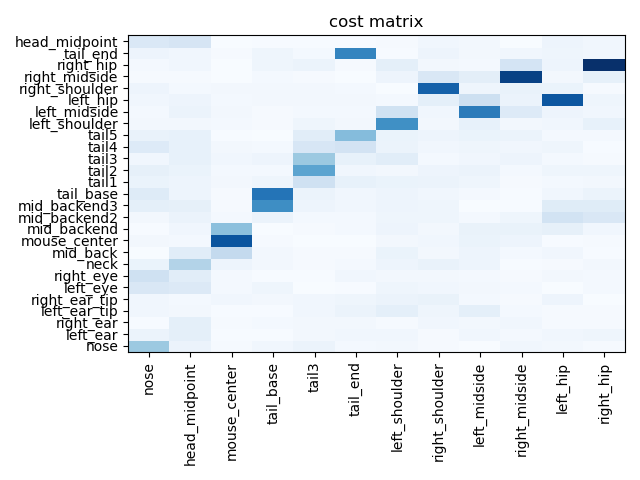

In [12]:
# I don't know if it will matter that I put hrnet_w32 and a specific detector in here.
# don't see why it should for keypoint matching? define model again in weight initialization and model training 
keypoint_matching(
    config_path,
    superanimal_name,
    "hrnet_w32",
    "fasterrcnn_resnet50_fpn_v2",
    copy_images=True,
)

conversion_table_path = project_path / "memory_replay" / "conversion_table.csv"
confusion_matrix_path = project_path / "memory_replay" / "confusion_matrix.png"

# You can visualize the pseudo predictions, or do pose embedding clustering etc.
pseudo_prediction_path = project_path / "memory_replay" / "pseudo_predictions.json"

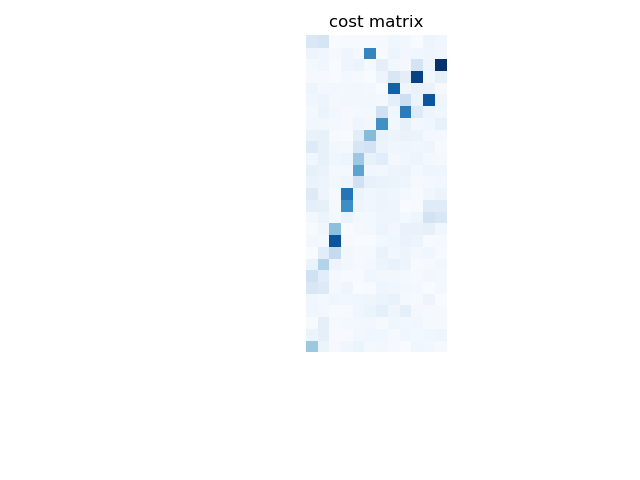

In [13]:
## display the confusion matrix 

confusion_matrix_image = Image.open(confusion_matrix_path)

plt.imshow(confusion_matrix_image)
plt.axis('off')  # Hide the axes for better view
plt.show()

In [14]:
# display the conversion table
df = pd.read_csv(conversion_table_path)
df = df.dropna()

df

,gt,MasterName
0,nose,nose
7,head_midpoint,neck
9,mouse_center,mouse_center
13,tail_base,tail_base
15,tail3,tail2
19,left_shoulder,left_shoulder
20,left_midside,left_midside
21,left_hip,left_hip
22,right_shoulder,right_shoulder
23,right_midside,right_midside


In [15]:
# create the conversion table and add to project's config file
create_conversion_table(
    config=config_path,
    super_animal=superanimal_name,
    project_to_super_animal=read_conversion_table_from_csv(
        conversion_table_path
    ),
)

ConversionTable(super_animal='superanimal_topviewmouse', project_bodyparts=['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip'], super_animal_bodyparts=['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'], table={'nose': 'nose', 'head_midpoint': 'neck', 'mouse_center': 'mouse_center', 'tail_base': 'tail_base', 'tail3': 'tail2', 'left_shoulder': 'left_shoulder', 'left_midside': 'left_midside', 'left_hip': 'left_hip', 'right_shoulder': 'right_shoulder', 'right_midside': 'right_midside', 'right_hip': 'right_hip', 'tail_end': 'tail_end'})

In [18]:
for shuffle, net in zip(sanft_shuffles, sanft_nets):               
    weight_init = build_weight_init(
        cfg=auxiliaryfunctions.read_config(config_path), 
        super_animal=superanimal_name,
        model_name=net,
        detector_name=None,
        with_decoder=True,
    )
    deeplabcut.create_training_dataset_from_existing_split(
        config_path,
        from_shuffle=base,
        shuffles=[shuffle],
        engine=deeplabcut.Engine.PYTORCH,
        net_type=net,
        weight_init=weight_init,
        userfeedback=False,
    )

You passed a split with the following fraction: 50%
You passed a split with the following fraction: 50%


In [8]:
for shuffle in sanft_shuffles: 
    start_time = time.perf_counter()
    deeplabcut.train_network(
        config_path,
        epochs=150,
        save_epochs=10,
        batch_size=64,  # if you get a CUDA OOM error when training on a GPU, reduce to 32, 16, ...!
        displayiters=10,
        shuffle=shuffle,
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time 
    print(f"Time for {shuffle}: {total_time} seconds")

Training with configuration:
data:
  colormode: RGB
  inference:
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
metadata:
  project_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13
  pose_config_path: /blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking_no_ears-grace-2025-09-13/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset50shuffle7/train/pytorch_config.yaml
  bodyparts: ['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip']
  unique_bodyparts: []
  individuals: ['animal']
  with_identity: False

Time for 7: 481.3007666529156 seconds


Loading pretrained model weights: WeightInitialization(snapshot_path=PosixPath('/blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_resnet_50.pt'), detector_snapshot_path=None, dataset='superanimal_topviewmouse', with_decoder=True, memory_replay=False, conversion_array=array([ 0,  7,  9, 13, 15, 25, 19, 22, 20, 23, 21, 24]), bodyparts=['nose', 'head_midpoint', 'mouse_center', 'tail_base', 'tail3', 'tail_end', 'left_shoulder', 'right_shoulder', 'left_midside', 'right_midside', 'left_hip', 'right_hip'])
The pose model is loading from /blue/adamdewan/gch22a.fsu/.conda/envs/DEEPLABCUT/lib/python3.12/site-packages/deeplabcut/modelzoo/checkpoints/superanimal_topviewmouse_resnet_50.pt
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y

Time for 8: 314.38749256997835 seconds


In [10]:
deeplabcut.evaluate_network(
    config_path,
    Shuffles=sanft_shuffles
)

Evaluation scorer: DLC_HrnetW32_benchmarkingSep4shuffle7_snapshot_best-140


100%|██████████| 152/152 [00:02<00:00, 68.21it/s]


Evaluation results file: DLC_HrnetW32_benchmarkingSep4shuffle7_snapshot_best-140-results.csv
Evaluation results for DLC_HrnetW32_benchmarkingSep4shuffle7_snapshot_best-140-results.csv (pcutoff: 0.6):
train rmse             6.14
train rmse_pcutoff     3.66
train mAP             64.95
train mAR             68.55
test rmse              7.95
test rmse_pcutoff      4.33
test mAP              57.79
test mAR              62.07
Name: (0.5, 7, 140, -1, 0.6), dtype: float64
Evaluation scorer: DLC_Resnet50_benchmarkingSep4shuffle8_snapshot_best-150


100%|██████████| 152/152 [00:00<00:00, 227.04it/s]


Evaluation results file: DLC_Resnet50_benchmarkingSep4shuffle8_snapshot_best-150-results.csv
Evaluation results for DLC_Resnet50_benchmarkingSep4shuffle8_snapshot_best-150-results.csv (pcutoff: 0.6):
train rmse            13.95
train rmse_pcutoff     5.23
train mAP             29.69
train mAR             35.39
test rmse             13.59
test rmse_pcutoff      4.89
test mAP              30.80
test mAR              36.27
Name: (0.5, 8, 150, -1, 0.6), dtype: float64


# Other useful code snippets

#### Continue training from a previous snapshot

In [ ]:
# continue training from last snapshot to increase performance
# set epochs and detector_epochs to the number of additional epochs you would like to perform
# snapshot_path is to the best/most recent snapshot 
deeplabcut.train_network(
    config_path, 
    epochs=100,
    save_epochs=10,
    batch_size=64,
    displayiters=10,
    shuffle=imagenet_transfer_learning_shuffle,
    snapshot_path="/blue/adamdewan/gch22a.fsu/DLC/Projects/benchmarking-grace-2025-09-04/dlc-models-pytorch/iteration-0/benchmarkingSep4-trainset95shuffle0/train/snapshot-best-050.pt"
)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [1.0, 1.0]
      translation: 0
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
    top_down_crop:
      width: 256
      height: 256
    auto_padding:
      pad_width_divisor: 32
      pad_height_divisor: 32
detector:
  data:
    colormode: RGB
    inference:
      normalize_images: True
    train:
      affine:
        p: 0.5
        rotation: 30
        scaling: [1.0, 1.0]
        translation: 40
      collate:
        type: ResizeFromDataSizeCollate
        min_scale: 0.4
        max_scale: 1.0
        min_short_side: 128
        max_short_side: 1152
        multiple_of: 32
        to_square: False
      hflip: True
      normalize_images: True
  device: